# **FRAMEWORK V7 - C16 INTERPRETACIÓN DE RESULTADOS**

Este notebook interpreta los resultados generados por **C15 - Evaluación de Modelos** sin volver a entrenar ni alterar los modelos.

Principios metodológicos de esta versión:

- La **partición de Prueba** conserva el rol de evaluación oficial.
- Las métricas globales se consideran únicamente descriptivas.
- Un resultado con evaluación limitada o un modelo que requiere ajustes **sigue siendo evidencia experimental válida**, pero no se presenta como desempeño satisfactorio.
- Las variables incluidas en el modelo se reportan como **variables representadas**, no como variables causalmente relevantes.
- C16 no modifica el modelo, no reescala datos y no recalcula predicciones: interpreta los artefactos reproducidos y validados por C15.
- El mismo notebook funciona para **Exp01 (clasificación)** y **Exp04 (regresión)** cambiando únicamente `EXPERIMENTO`.

## **M0. Configuración del experimento**

Seleccione el experimento que se desea interpretar. No cambie las rutas restantes.

In [19]:
import os
import io
import time
import math
import shutil
import hashlib
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display, Markdown
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

#==========================================================================================
# SCRIPT 70
# CONFIGURACIÓN DEL EXPERIMENTO
#==========================================================================================

EXPERIMENTO = "Exp01"       # Cambiar únicamente a "Exp04" para el experimento de regresión

BASE_GITHUB = (
    "https://raw.githubusercontent.com/"
    "jriatiga/FRAMEWORK_V7/refs/heads/main/DATA"
)

# Correcting BASE_EVALUACIONES to include 'EVALUACIONES' based on user's provided paths.
BASE_EVALUACIONES = f"{BASE_GITHUB}/EVALUACIONES/{EXPERIMENTO}"

CARPETA_INTERPRETACION = f"interpretacion/{EXPERIMENTO}"
os.makedirs(CARPETA_INTERPRETACION, exist_ok=True)

print()
print("=" * 90)
print("FRAMEWORK V7 - C16 INTERPRETACIÓN DE RESULTADOS")
print("=" * 90)
print()
print(f"Experimento seleccionado : {EXPERIMENTO}")
print(f"Fuente C15                : {BASE_EVALUACIONES}")
print(f"Salida local              : {CARPETA_INTERPRETACION}")


FRAMEWORK V7 - C16 INTERPRETACIÓN DE RESULTADOS

Experimento seleccionado : Exp01
Fuente C15                : https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/EVALUACIONES/Exp01
Salida local              : interpretacion/Exp01


## **M1. Librerías y funciones generales**

In [20]:
import os
import time
import math
import shutil
import hashlib
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO, BytesIO

from IPython.display import display, Markdown
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")
os.makedirs(CARPETA_INTERPRETACION, exist_ok=True)


def normalizar_texto(valor):
    texto = "" if valor is None else str(valor)
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return " ".join(texto.lower().strip().split())


def es_clasificacion(tipo):
    return normalizar_texto(tipo).startswith("clas")


def es_regresion(tipo):
    return normalizar_texto(tipo).startswith("reg")


def a_bool(valor):
    if isinstance(valor, (bool, np.bool_)):
        return bool(valor)
    if pd.isna(valor):
        return False
    return normalizar_texto(valor) in {"true", "verdadero", "1", "si", "yes"}


def obtener_parametro(df, parametro, obligatorio=True, default=None):
    if not {"Parametro", "Valor"}.issubset(df.columns):
        raise ValueError("La metadata debe contener las columnas Parametro y Valor.")

    mascara = df["Parametro"].astype(str).map(normalizar_texto) == normalizar_texto(parametro)
    valores = df.loc[mascara, "Valor"]

    if len(valores) == 0:
        if obligatorio:
            raise KeyError(f"No se encontró el parámetro obligatorio: {parametro}")
        return default

    return valores.iloc[0]


def leer_csv_github(nombre_archivo, obligatorio=True):
    base_name, original_ext = os.path.splitext(nombre_archivo)

    # List of (filename_to_try, extension_to_use_for_read_function)
    try_files = [(nombre_archivo, original_ext)]

    # If the original request was for a CSV, also try XLSX
    if original_ext.lower() == '.csv':
        try_files.append((base_name + '.xlsx', '.xlsx'))

    for current_nombre_archivo, current_ext in try_files:
        url = f"{BASE_EVALUACIONES}/{current_nombre_archivo}"
        params = {"v": str(int(time.time()))}

        try:
            respuesta = requests.get(url, params=params, timeout=60)
            respuesta.raise_for_status()
            contenido = respuesta.content

            if current_ext.lower() == ".csv":
                df = pd.read_csv(StringIO(contenido.decode("utf-8-sig")))
            elif current_ext.lower() == ".xlsx":
                df = pd.read_excel(BytesIO(contenido))
            else:
                # If an unsupported extension was requested, and it got this far, it's an issue
                raise ValueError(f"Unsupported file extension: {current_ext}")

            return df, respuesta.url

        except requests.exceptions.HTTPError as http_exc:
            if http_exc.response.status_code == 404 and current_ext.lower() == '.csv' and any(f[1].lower() == '.xlsx' for f in try_files):
                # If it's a 404 for CSV and an XLSX alternative exists, continue to try XLSX
                continue
            else:
                # Re-raise for other HTTP errors or if no alternative exists
                if obligatorio:
                    raise RuntimeError(
                        f"No fue posible cargar el archivo obligatorio {current_nombre_archivo}: {http_exc}"
                    ) from http_exc
                return pd.DataFrame(), url # Or return empty DataFrame if not obligatory
        except Exception as exc:
            # Catch other exceptions (e.g., pd.read_csv/excel errors)
            if obligatorio:
                raise RuntimeError(
                    f"No fue posible cargar el archivo obligatorio {current_nombre_archivo}: {exc}"
                ) from exc
            return pd.DataFrame(), url

    # If we reached here, it means all attempts failed and none of the exceptions were re-raised
    if obligatorio:
        raise RuntimeError(f"No fue posible cargar el archivo obligatorio {nombre_archivo}: Both CSV and XLSX attempts failed to load.")
    return pd.DataFrame(), url


def sha256_archivo(ruta):
    h = hashlib.sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()


def valor_numerico(fila, columna, default=np.nan):
    if columna not in fila.index:
        return default
    return pd.to_numeric(pd.Series([fila[columna]]), errors="coerce").iloc[0]


print()
print("=" * 90)
print("LIBRERÍAS Y FUNCIONES CARGADAS")
print("=" * 90)



LIBRERÍAS Y FUNCIONES CARGADAS


## **M2. Carga automática de artefactos de C15**

C16 consume directamente los artefactos publicados por C15. `baselines.csv` es opcional y solo se espera para regresión.

In [21]:
#==========================================================================================
# SCRIPT 72
# CARGA DE ARTEFACTOS C15
#==========================================================================================

metadata_prediccion, URL_METADATA = leer_csv_github(
    "metadata_prediccion.csv",
    obligatorio=True
)

TIPO_PROBLEMA = str(
    obtener_parametro(metadata_prediccion, "Tipo Problema")
)

predicciones, URL_PREDICCIONES = leer_csv_github(
    "predicciones.csv",
    obligatorio=True
)

predicciones_prueba, URL_PREDICCIONES_PRUEBA = leer_csv_github(
    "predicciones_prueba.csv",
    obligatorio=True
)

metricas_particiones, URL_METRICAS = leer_csv_github(
    "metricas_particiones.csv",
    obligatorio=True
)

metricas_por_nodo, URL_METRICAS_NODO = leer_csv_github(
    "metricas_por_nodo.csv",
    obligatorio=True
)

validacion_integridad_c15, URL_VALIDACION = leer_csv_github(
    "validacion_integridad.csv",
    obligatorio=True
)

manifiesto_c15, URL_MANIFIESTO = leer_csv_github(
    f"manifiesto_artefactos_C15_{EXPERIMENTO}.csv",
    obligatorio=False
)

if es_regresion(TIPO_PROBLEMA):
    baselines, URL_BASELINES = leer_csv_github(
        "baselines.csv",
        obligatorio=True
    )
else:
    baselines = pd.DataFrame()
    URL_BASELINES = "No aplica"

#------------------------------------------------------------------------------------------
# Recuperar configuración documentada por C15
#------------------------------------------------------------------------------------------

EXPERIMENTO_METADATA = str(
    obtener_parametro(metadata_prediccion, "Experimento")
)
DOMINIO = str(
    obtener_parametro(metadata_prediccion, "Dominio")
)
VARIABLE_OBJETIVO = str(
    obtener_parametro(metadata_prediccion, "Variable Objetivo")
)
VARIABLE_OBJETIVO_CIENTIFICO = str(
    obtener_parametro(
        metadata_prediccion,
        "Variable Objetivo Cientifico",
        obligatorio=False,
        default=VARIABLE_OBJETIVO
    )
)
NOMBRE_MODELO = str(
    obtener_parametro(metadata_prediccion, "Modelo")
)
METODO_TRANSFORMACION = str(
    obtener_parametro(metadata_prediccion, "Metodo Transformacion")
)
VENTANA = int(float(
    obtener_parametro(metadata_prediccion, "Ventana")
))
HORIZONTE = int(float(
    obtener_parametro(metadata_prediccion, "Horizonte")
))
NUM_VARIABLES = int(float(
    obtener_parametro(metadata_prediccion, "Variables Predictoras")
))
VARIABLES_MODELO = [
    v.strip()
    for v in str(
        obtener_parametro(metadata_prediccion, "Variables Modelo")
    ).split(";")
    if v.strip()
]
ESTADO_C14 = str(
    obtener_parametro(metadata_prediccion, "Estado C14")
)
ESTADO_C15 = str(
    obtener_parametro(metadata_prediccion, "Estado C15")
)
ESTADOS_COINCIDEN = a_bool(
    obtener_parametro(metadata_prediccion, "Estados Coinciden")
)

# Fechas para análisis temporal.
for df in [predicciones, predicciones_prueba]:
    for columna in ["Fecha_Inicio", "Fecha_Fin", "Fecha_Objetivo"]:
        if columna in df.columns:
            df[columna] = pd.to_datetime(df[columna], errors="coerce")

print()
print("=" * 90)
print("ARTEFACTOS C15 CARGADOS")
print("=" * 90)
print()
print(f"Experimento                  : {EXPERIMENTO_METADATA}")
print(f"Dominio                      : {DOMINIO}")
print(f"Tipo de problema             : {TIPO_PROBLEMA}")
print(f"Objetivo del modelo          : {VARIABLE_OBJETIVO}")
print(f"Objetivo científico          : {VARIABLE_OBJETIVO_CIENTIFICO}")
print(f"Modelo                       : {NOMBRE_MODELO}")
print(f"Ventana / horizonte          : {VENTANA} / {HORIZONTE}")
print(f"Predictoras                  : {NUM_VARIABLES}")
print(f"Estado C14                   : {ESTADO_C14}")
print(f"Estado C15                   : {ESTADO_C15}")
print(f"Estados C14/C15 coinciden    : {ESTADOS_COINCIDEN}")
print()
print(f"Predicciones                 : {len(predicciones)}")
print(f"Predicciones de prueba       : {len(predicciones_prueba)}")
print(f"Métricas por partición       : {len(metricas_particiones)} filas")
print(f"Métricas por nodo            : {len(metricas_por_nodo)} filas")


ARTEFACTOS C15 CARGADOS

Experimento                  : Exp01
Dominio                      : Gestión Hídrica
Tipo de problema             : Clasificación
Objetivo del modelo          : nivel_de_riesgo
Objetivo científico          : irca
Modelo                       : modelo_Exp01_nivel_de_riesgo.keras
Ventana / horizonte          : 12 / 1
Predictoras                  : 8
Estado C14                   : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado C15                   : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estados C14/C15 coinciden    : True

Predicciones                 : 480
Predicciones de prueba       : 72
Métricas por partición       : 4 filas
Métricas por nodo            : 4 filas


## **M3. Validación integral de la evidencia recibida**

Esta validación comprueba la consistencia de los archivos de C15. **No exige que el modelo tenga buen desempeño**; un modelo que requiere ajustes puede ser interpretado siempre que sus artefactos sean íntegros y reproducibles.

In [22]:
#==========================================================================================
# SCRIPT 73
# VALIDACIÓN INTEGRAL DE LOS ARTEFACTOS C15
#==========================================================================================

columnas_comunes = {
    "Indice_Secuencia",
    "Nodo",
    "Fecha_Objetivo",
    "Particion",
    "Real",
    "Prediccion"
}

columnas_tipo = (
    {"Probabilidad", "Correcto"}
    if es_clasificacion(TIPO_PROBLEMA)
    else {"Error", "Error_Absoluto"}
)

faltantes_predicciones = sorted(
    (columnas_comunes | columnas_tipo) - set(predicciones.columns)
)

# Integridad que C15 ya verificó contra modelo, tensores y scalers de C14.
if {"Control", "Estado"}.issubset(validacion_integridad_c15.columns):
    estados_integridad_c15 = validacion_integridad_c15["Estado"].map(a_bool)
    integridad_c15_ok = bool(estados_integridad_c15.all())
else:
    integridad_c15_ok = False

# Alinear la partición de prueba con predicciones.csv.
df_test = predicciones.loc[
    predicciones["Particion"].astype(str).map(normalizar_texto) == "prueba"
].copy()

ids_test = set(
    pd.to_numeric(df_test["Indice_Secuencia"], errors="coerce").dropna().astype(int)
) if "Indice_Secuencia" in df_test.columns else set()

ids_archivo_test = set(
    pd.to_numeric(
        predicciones_prueba["Indice_Secuencia"],
        errors="coerce"
    ).dropna().astype(int)
) if "Indice_Secuencia" in predicciones_prueba.columns else set()

# Identificar la fila oficial de prueba en métricas.
mascara_prueba_metricas = (
    metricas_particiones["Particion"].astype(str).map(normalizar_texto) == "prueba"
    if "Particion" in metricas_particiones.columns
    else pd.Series(False, index=metricas_particiones.index)
)

metricas_test_df = metricas_particiones.loc[mascara_prueba_metricas].copy()

n_metricas_test = (
    int(pd.to_numeric(metricas_test_df["N"], errors="coerce").iloc[0])
    if len(metricas_test_df) == 1 and "N" in metricas_test_df.columns
    else -1
)

controles_c16_fuente = {
    "Experimento_metadata_coincide": normalizar_texto(EXPERIMENTO_METADATA) == normalizar_texto(EXPERIMENTO),
    "Tipo_problema_soportado": es_clasificacion(TIPO_PROBLEMA) or es_regresion(TIPO_PROBLEMA),
    "Numero_predictoras_coincide": len(VARIABLES_MODELO) == NUM_VARIABLES,
    "Integridad_C15_exitosa": integridad_c15_ok,
    "Estados_C14_C15_coinciden": ESTADOS_COINCIDEN,
    "Columnas_predicciones_completas": len(faltantes_predicciones) == 0,
    "Particion_prueba_presente": len(df_test) > 0,
    "Archivo_prueba_alineado": ids_test == ids_archivo_test and len(ids_test) > 0,
    "Una_fila_metricas_prueba": len(metricas_test_df) == 1,
    "N_metricas_prueba_coincide": n_metricas_test == len(df_test),
    "Sin_NaN_real_prueba": not pd.to_numeric(df_test["Real"], errors="coerce").isna().any(),
    "Sin_NaN_prediccion_prueba": not pd.to_numeric(df_test["Prediccion"], errors="coerce").isna().any(),
    "Fechas_objetivo_prueba_validas": not df_test["Fecha_Objetivo"].isna().any()
}

validacion_fuente_c16 = pd.DataFrame({
    "Control": list(controles_c16_fuente.keys()),
    "Estado": list(controles_c16_fuente.values())
})

print()
print("=" * 90)
print("VALIDACIÓN DE LA EVIDENCIA C15")
print("=" * 90)
print()
display(validacion_fuente_c16)

if faltantes_predicciones:
    print()
    print("Columnas faltantes:", faltantes_predicciones)

if not all(controles_c16_fuente.values()):
    raise ValueError(
        "C16 detectó inconsistencias en los artefactos de C15. "
        "No es metodológicamente seguro continuar con la interpretación."
    )

print()
print("Resultado : EVIDENCIA C15 ÍNTEGRA Y CONSISTENTE")


VALIDACIÓN DE LA EVIDENCIA C15



,Control,Estado
0,Experimento_metadata_coincide,True
1,Tipo_problema_soportado,True
2,Numero_predictoras_coincide,True
3,Integridad_C15_exitosa,True
4,Estados_C14_C15_coinciden,True
5,Columnas_predicciones_completas,True
6,Particion_prueba_presente,True
7,Archivo_prueba_alineado,True
8,Una_fila_metricas_prueba,True
9,N_metricas_prueba_coincide,True



Resultado : EVIDENCIA C15 ÍNTEGRA Y CONSISTENTE


## **M4. Interpretación del desempeño predictivo**

La decisión sobre el modelo se conserva exactamente como fue registrada por C15. C16 contextualiza las métricas, pero **no cambia el estado del modelo**.

In [23]:
#==========================================================================================
# SCRIPT 74
# MÉTRICAS OFICIALES DE PRUEBA Y ESTADO DE INTERPRETACIÓN
#==========================================================================================

met_test = metricas_test_df.iloc[0]

if "Global_Descriptivo" in metricas_particiones.get("Particion", pd.Series(dtype=str)).astype(str).values:
    metricas_global_df = metricas_particiones.loc[
        metricas_particiones["Particion"].astype(str) == "Global_Descriptivo"
    ].copy()
else:
    metricas_global_df = pd.DataFrame()

estado_norm = normalizar_texto(ESTADO_C15)

if "evaluacion limitada" in estado_norm:
    ESTADO_INTERPRETACION_C16 = (
        "INTERPRETACION LIMITADA - EVIDENCIA PREDICTIVA INSUFICIENTE EN TEST"
    )
elif "requiere ajustes" in estado_norm:
    ESTADO_INTERPRETACION_C16 = (
        "INTERPRETACION DESCRIPTIVA - MODELO NO APROBADO"
    )
elif "aceptable" in estado_norm:
    ESTADO_INTERPRETACION_C16 = (
        "INTERPRETACION CON SOPORTE PREDICTIVO MODERADO"
    )
elif "aprobado" in estado_norm:
    ESTADO_INTERPRETACION_C16 = (
        "INTERPRETACION CON SOPORTE PREDICTIVO"
    )
else:
    ESTADO_INTERPRETACION_C16 = (
        "INTERPRETACION CON ESTADO DE MODELO NO CLASIFICADO"
    )

print()
print("=" * 90)
print("DESEMPEÑO OFICIAL - PARTICIÓN DE PRUEBA")
print("=" * 90)
print()
display(metricas_test_df)

if len(baselines) > 0:
    print()
    print("Baselines reportados por C15:")
    display(baselines)

print()
print(f"Estado C15                  : {ESTADO_C15}")
print(f"Estado interpretación C16  : {ESTADO_INTERPRETACION_C16}")


DESEMPEÑO OFICIAL - PARTICIÓN DE PRUEBA



,Particion,N,Accuracy,Precision,Recall,F1,Especificidad,Accuracy_Balanceada,AUC_ROC,Clases_Presentes
2,Prueba,72,1.0,0.0,0.0,0.0,1.0,0.5,NaN,1



Estado C15                  : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado interpretación C16  : INTERPRETACION LIMITADA - EVIDENCIA PREDICTIVA INSUFICIENTE EN TEST


In [24]:
#==========================================================================================
# SCRIPT 75
# INTERPRETACIÓN ESPECÍFICA SEGÚN TIPO DE PROBLEMA
#==========================================================================================

interpretacion_metricas = []

if es_clasificacion(TIPO_PROBLEMA):
    clases_presentes = int(valor_numerico(met_test, "Clases_Presentes", 0))
    accuracy = valor_numerico(met_test, "Accuracy")
    precision = valor_numerico(met_test, "Precision")
    recall = valor_numerico(met_test, "Recall")
    f1 = valor_numerico(met_test, "F1")
    especificidad = valor_numerico(met_test, "Especificidad")
    accuracy_balanceada = valor_numerico(met_test, "Accuracy_Balanceada")
    auc = valor_numerico(met_test, "AUC_ROC")

    interpretacion_metricas.extend([
        {"Indicador": "Accuracy", "Valor": accuracy, "Interpretacion": "Proporción total de aciertos en prueba."},
        {"Indicador": "Precision", "Valor": precision, "Interpretacion": "Confiabilidad de las predicciones positivas; debe interpretarse junto con la presencia de ambas clases."},
        {"Indicador": "Recall", "Valor": recall, "Interpretacion": "Capacidad de detectar la clase positiva; no es concluyente si la clase positiva no aparece en prueba."},
        {"Indicador": "F1", "Valor": f1, "Interpretacion": "Balance entre precisión y recall para la clase positiva."},
        {"Indicador": "Especificidad", "Valor": especificidad, "Interpretacion": "Capacidad de reconocer la clase negativa."},
        {"Indicador": "Accuracy Balanceada", "Valor": accuracy_balanceada, "Interpretacion": "Promedia sensibilidad y especificidad para reducir el efecto del desbalance."},
        {"Indicador": "AUC ROC", "Valor": auc, "Interpretacion": "Solo es evaluable cuando existen al menos dos clases en la partición."},
        {"Indicador": "Clases presentes en Test", "Valor": clases_presentes, "Interpretacion": "Determina si la evaluación discriminativa del clasificador es completa."}
    ])

    if clases_presentes < 2:
        MENSAJE_DESEMPENO = (
            "La partición de prueba contiene una sola clase. Por ello, la accuracy puede ser alta "
            "sin demostrar capacidad para discriminar la clase positiva. Precision, recall, F1 y AUC "
            "no deben utilizarse para declarar un desempeño general satisfactorio."
        )
    else:
        MENSAJE_DESEMPENO = (
            "La partición de prueba contiene ambas clases y permite una evaluación discriminativa completa. "
            "La decisión debe priorizar F1, accuracy balanceada y AUC sobre la accuracy aislada."
        )

else:
    mae = valor_numerico(met_test, "MAE")
    rmse = valor_numerico(met_test, "RMSE")
    nmae = valor_numerico(met_test, "NMAE_%")
    nrmse = valor_numerico(met_test, "NRMSE_%")
    mape = valor_numerico(met_test, "MAPE_%")
    r2 = valor_numerico(met_test, "R2")

    interpretacion_metricas.extend([
        {"Indicador": "MAE", "Valor": mae, "Interpretacion": "Error absoluto medio en unidades originales del objetivo."},
        {"Indicador": "RMSE", "Valor": rmse, "Interpretacion": "Penaliza con mayor peso los errores grandes."},
        {"Indicador": "NMAE_%", "Valor": nmae, "Interpretacion": "MAE normalizado respecto al nivel medio absoluto del objetivo."},
        {"Indicador": "NRMSE_%", "Valor": nrmse, "Interpretacion": "RMSE normalizado respecto al nivel medio absoluto del objetivo."},
        {"Indicador": "MAPE_%", "Valor": mape, "Interpretacion": "Error porcentual absoluto medio cuando el valor real es distinto de cero."},
        {"Indicador": "R2", "Valor": r2, "Interpretacion": "Capacidad de explicar la variabilidad observada en prueba."}
    ])

    if np.isfinite(r2) and r2 < 0:
        MENSAJE_DESEMPENO = (
            "El R² de prueba es negativo: el modelo no explica adecuadamente la variabilidad temporal del objetivo "
            "en el periodo de prueba. Los errores porcentuales pueden ser moderados y, aun así, coexistir con un R² "
            "negativo cuando el modelo aproxima el nivel general pero no reproduce bien las variaciones."
        )
    elif np.isfinite(r2) and r2 >= 0.5:
        MENSAJE_DESEMPENO = (
            "El modelo presenta capacidad explicativa moderada o superior en la partición de prueba."
        )
    else:
        MENSAJE_DESEMPENO = (
            "La capacidad explicativa de prueba es limitada y debe contrastarse con los baselines antes de considerar uso operacional."
        )

interpretacion_metricas = pd.DataFrame(interpretacion_metricas)

print()
print("=" * 90)
print("INTERPRETACIÓN DE LAS MÉTRICAS")
print("=" * 90)
print()
print(MENSAJE_DESEMPENO)
print()
display(interpretacion_metricas)


INTERPRETACIÓN DE LAS MÉTRICAS

La partición de prueba contiene una sola clase. Por ello, la accuracy puede ser alta sin demostrar capacidad para discriminar la clase positiva. Precision, recall, F1 y AUC no deben utilizarse para declarar un desempeño general satisfactorio.



,Indicador,Valor,Interpretacion
0,Accuracy,1.0,Proporción total de aciertos en prueba.
1,Precision,0.0,Confiabilidad de las predicciones positivas; d...
2,Recall,0.0,Capacidad de detectar la clase positiva; no es...
3,F1,0.0,Balance entre precisión y recall para la clase...
4,Especificidad,1.0,Capacidad de reconocer la clase negativa.
5,Accuracy Balanceada,0.5,Promedia sensibilidad y especificidad para red...
6,AUC ROC,NaN,Solo es evaluable cuando existen al menos dos ...
7,Clases presentes en Test,1.0,Determina si la evaluación discriminativa del ...


## **M5. Comportamiento temporal y heterogeneidad por nodo**

Esta sección analiza cómo se distribuyen las predicciones y errores a lo largo del tiempo y entre nodos. El análisis es descriptivo y no implica causalidad.

In [25]:
#==========================================================================================
# SCRIPT 76
# RESUMEN TEMPORAL Y POR NODO EN PRUEBA
#==========================================================================================

resumen_temporal_nodo = []

for nodo, grupo in df_test.groupby("Nodo", sort=True):
    grupo = grupo.sort_values("Fecha_Objetivo").copy()

    if es_clasificacion(TIPO_PROBLEMA):
        y_real = grupo["Real"].astype(int).to_numpy()
        y_pred = grupo["Prediccion"].astype(int).to_numpy()
        prob = grupo["Probabilidad"].astype(float).to_numpy()
        clases = len(np.unique(y_real))

        resumen_temporal_nodo.append({
            "Nodo": nodo,
            "N": len(grupo),
            "Fecha_Inicial": grupo["Fecha_Objetivo"].min(),
            "Fecha_Final": grupo["Fecha_Objetivo"].max(),
            "Clases_Presentes": clases,
            "Tasa_Real_Clase_1_%": 100 * np.mean(y_real == 1),
            "Tasa_Predicha_Clase_1_%": 100 * np.mean(y_pred == 1),
            "Probabilidad_Media": float(np.mean(prob)),
            "Accuracy": accuracy_score(y_real, y_pred),
            "F1": f1_score(y_real, y_pred, zero_division=0) if clases >= 2 else np.nan,
            "Recall": recall_score(y_real, y_pred, zero_division=0) if clases >= 2 else np.nan
        })

    else:
        y_real = grupo["Real"].astype(float).to_numpy()
        y_pred = grupo["Prediccion"].astype(float).to_numpy()
        errores = y_real - y_pred
        mae_nodo = mean_absolute_error(y_real, y_pred)
        rmse_nodo = math.sqrt(mean_squared_error(y_real, y_pred))
        mascara = np.abs(y_real) > 1e-12
        mape_nodo = (
            np.mean(np.abs((y_real[mascara] - y_pred[mascara]) / y_real[mascara])) * 100
            if mascara.any()
            else np.nan
        )
        r2_nodo = r2_score(y_real, y_pred) if len(y_real) >= 2 else np.nan

        resumen_temporal_nodo.append({
            "Nodo": nodo,
            "N": len(grupo),
            "Fecha_Inicial": grupo["Fecha_Objetivo"].min(),
            "Fecha_Final": grupo["Fecha_Objetivo"].max(),
            "Real_Medio": float(np.mean(y_real)),
            "Prediccion_Media": float(np.mean(y_pred)),
            "Sesgo_Real_menos_Pred": float(np.mean(errores)),
            "MAE": mae_nodo,
            "RMSE": rmse_nodo,
            "MAPE_%": mape_nodo,
            "R2": r2_nodo
        })

resumen_temporal_nodo = pd.DataFrame(resumen_temporal_nodo)

print()
print("=" * 90)
print("RESUMEN DE PRUEBA POR NODO")
print("=" * 90)
print()
display(resumen_temporal_nodo)


RESUMEN DE PRUEBA POR NODO



,Nodo,N,Fecha_Inicial,Fecha_Final,Clases_Presentes,Tasa_Real_Clase_1_%,Tasa_Predicha_Clase_1_%,Probabilidad_Media,Accuracy,F1,Recall
0,Bogota_Sabana,18,2024-07-01,2025-12-01,1,0.0,0.0,0.327331,1.0,NaN,NaN
1,Sopo_Sur,18,2024-07-01,2025-12-01,1,0.0,0.0,0.094049,1.0,NaN,NaN
2,Tocancipa_Media,18,2024-07-01,2025-12-01,1,0.0,0.0,0.115431,1.0,NaN,NaN
3,Villapinzon_Alta,18,2024-07-01,2025-12-01,1,0.0,0.0,0.247057,1.0,NaN,NaN


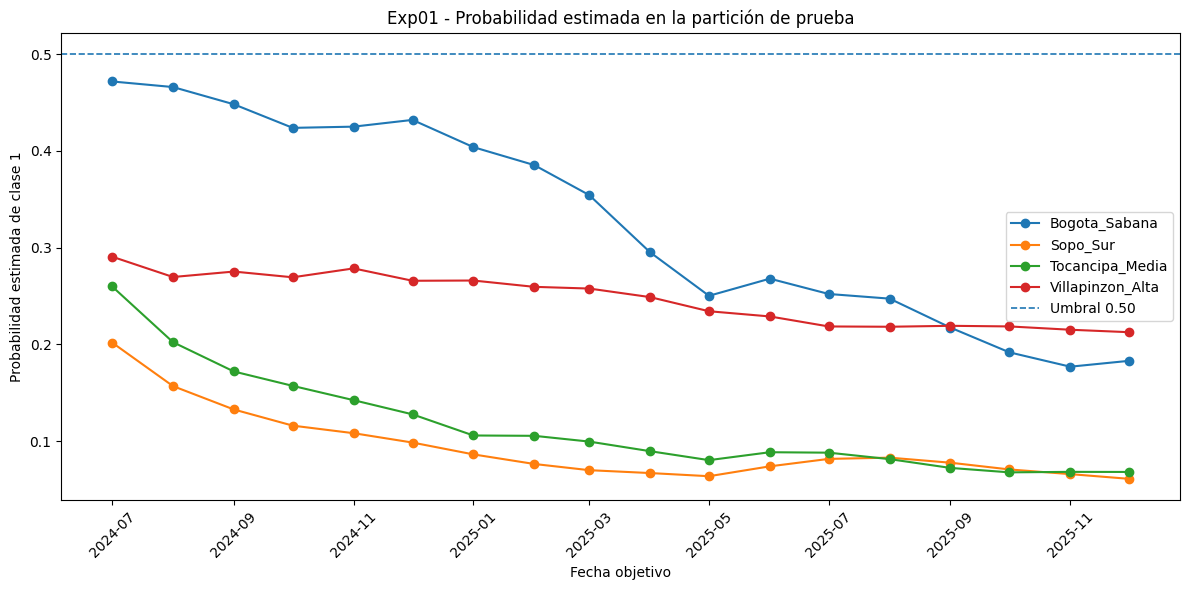

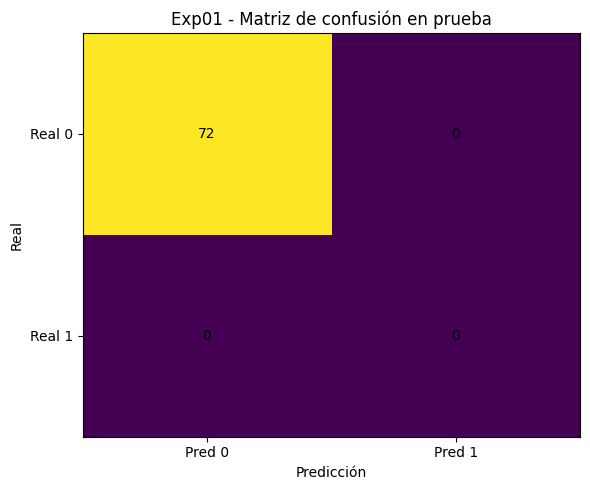


Gráficos generados:
- interpretacion/Exp01/probabilidad_temporal_Exp01.png
- interpretacion/Exp01/matriz_confusion_C16_Exp01.png


In [26]:
#==========================================================================================
# SCRIPT 77
# GRÁFICOS DE INTERPRETACIÓN TEMPORAL
#==========================================================================================

ARCHIVOS_GRAFICOS = []

#------------------------------------------------------------------------------------------
# Gráfico 1: comportamiento temporal
#------------------------------------------------------------------------------------------

if es_clasificacion(TIPO_PROBLEMA):
    ruta_temporal = os.path.join(
        CARPETA_INTERPRETACION,
        f"probabilidad_temporal_{EXPERIMENTO}.png"
    )

    plt.figure(figsize=(12, 6))
    for nodo, grupo in df_test.groupby("Nodo", sort=True):
        grupo = grupo.sort_values("Fecha_Objetivo")
        plt.plot(
            grupo["Fecha_Objetivo"],
            grupo["Probabilidad"].astype(float),
            marker="o",
            linewidth=1.5,
            label=str(nodo)
        )

    plt.axhline(0.5, linestyle="--", linewidth=1.2, label="Umbral 0.50")
    plt.xlabel("Fecha objetivo")
    plt.ylabel("Probabilidad estimada de clase 1")
    plt.title(f"{EXPERIMENTO} - Probabilidad estimada en la partición de prueba")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ruta_temporal, dpi=180, bbox_inches="tight")
    plt.show()
    ARCHIVOS_GRAFICOS.append(ruta_temporal)

    # Matriz de confusión reconstruida desde las predicciones publicadas por C15.
    ruta_matriz = os.path.join(
        CARPETA_INTERPRETACION,
        f"matriz_confusion_C16_{EXPERIMENTO}.png"
    )

    cm = confusion_matrix(
        df_test["Real"].astype(int),
        df_test["Prediccion"].astype(int),
        labels=[0, 1]
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, aspect="auto")
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["Real 0", "Real 1"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"{EXPERIMENTO} - Matriz de confusión en prueba")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(ruta_matriz, dpi=180, bbox_inches="tight")
    plt.show()
    ARCHIVOS_GRAFICOS.append(ruta_matriz)

else:
    # Promedio mensual entre nodos para visualizar tendencia general sin mezclar líneas excesivamente.
    serie_mensual = (
        df_test
        .groupby("Fecha_Objetivo", as_index=False)
        .agg(
            Real=("Real", "mean"),
            Prediccion=("Prediccion", "mean")
        )
        .sort_values("Fecha_Objetivo")
    )

    ruta_temporal = os.path.join(
        CARPETA_INTERPRETACION,
        f"real_vs_pred_temporal_{EXPERIMENTO}.png"
    )

    plt.figure(figsize=(12, 6))
    plt.plot(
        serie_mensual["Fecha_Objetivo"],
        serie_mensual["Real"],
        marker="o",
        label="Real"
    )
    plt.plot(
        serie_mensual["Fecha_Objetivo"],
        serie_mensual["Prediccion"],
        marker="o",
        label="Predicción"
    )
    plt.xlabel("Fecha objetivo")
    plt.ylabel(VARIABLE_OBJETIVO)
    plt.title(f"{EXPERIMENTO} - Real vs predicción en prueba (promedio entre nodos)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ruta_temporal, dpi=180, bbox_inches="tight")
    plt.show()
    ARCHIVOS_GRAFICOS.append(ruta_temporal)

    ruta_residuos = os.path.join(
        CARPETA_INTERPRETACION,
        f"residuos_temporales_{EXPERIMENTO}.png"
    )

    plt.figure(figsize=(12, 6))
    for nodo, grupo in df_test.groupby("Nodo", sort=True):
        grupo = grupo.sort_values("Fecha_Objetivo")
        error = grupo["Real"].astype(float) - grupo["Prediccion"].astype(float)
        plt.plot(
            grupo["Fecha_Objetivo"],
            error,
            marker="o",
            linewidth=1.5,
            label=str(nodo)
        )
    plt.axhline(0, linestyle="--", linewidth=1.2)
    plt.xlabel("Fecha objetivo")
    plt.ylabel("Error = Real - Predicción")
    plt.title(f"{EXPERIMENTO} - Residuos temporales en prueba")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ruta_residuos, dpi=180, bbox_inches="tight")
    plt.show()
    ARCHIVOS_GRAFICOS.append(ruta_residuos)

print()
print("Gráficos generados:")
for ruta in ARCHIVOS_GRAFICOS:
    print("-", ruta)

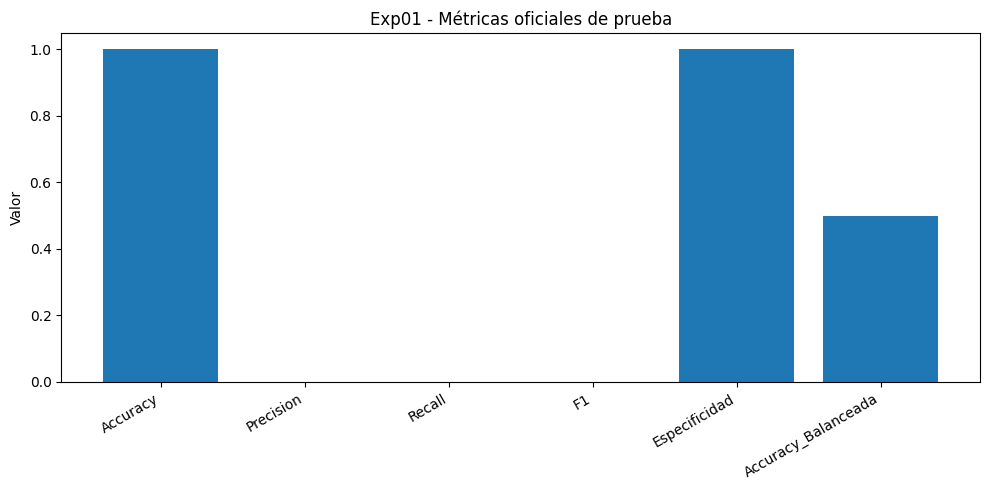

In [27]:
#==========================================================================================
# SCRIPT 78
# GRÁFICO DE MÉTRICAS OFICIALES
#==========================================================================================

ruta_metricas = os.path.join(
    CARPETA_INTERPRETACION,
    f"metricas_prueba_{EXPERIMENTO}.png"
)

if es_clasificacion(TIPO_PROBLEMA):
    nombres = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Especificidad",
        "Accuracy_Balanceada"
    ]
else:
    nombres = [
        "NMAE_%",
        "NRMSE_%",
        "MAPE_%"
    ]

valores = [
    valor_numerico(met_test, nombre)
    for nombre in nombres
]

mascara = [np.isfinite(v) for v in valores]
nombres_graf = [n for n, ok in zip(nombres, mascara) if ok]
valores_graf = [v for v, ok in zip(valores, mascara) if ok]

plt.figure(figsize=(10, 5))
plt.bar(nombres_graf, valores_graf)
plt.ylabel("Valor")
plt.title(f"{EXPERIMENTO} - Métricas oficiales de prueba")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ruta_metricas, dpi=180, bbox_inches="tight")
plt.show()

ARCHIVOS_GRAFICOS.append(ruta_metricas)

## **M6. Variables y dimensiones representadas**

Esta sección **no calcula importancia de variables**. Reporta cuáles variables entraron realmente al modelo y qué dimensiones del sistema representan. La inclusión de una variable no demuestra causalidad ni relevancia individual.

In [28]:
#==========================================================================================
# SCRIPT 79
# VARIABLES Y DIMENSIONES REPRESENTADAS
#==========================================================================================

MAPA_DIMENSIONES = {
    "Climática": {
        "ONI",
        "Precipitacion_mm",
        "Radiacion_Solar",
        "Humedad_Relativa",
        "Temp_Min_C",
        "Mes",
        "Velocidad_Viento"
    },
    "Hidrológica": {
        "VolumenUtilDiarioMasa"
    },
    "Calidad del agua": {
        "irca"
    },
    "Saneamiento / institucional": {
        "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS"
    }
}


def dimension_de_variable(variable):
    for dimension, variables in MAPA_DIMENSIONES.items():
        if variable in variables:
            return dimension
    return "Otra"


variables_dimensiones = pd.DataFrame({
    "Variable": VARIABLES_MODELO
})
variables_dimensiones["Dimension"] = variables_dimensiones["Variable"].map(
    dimension_de_variable
)
variables_dimensiones["Rol"] = "Predictora"
variables_dimensiones["Interpretacion"] = (
    "Variable utilizada por el modelo; su presencia no implica causalidad ni importancia individual."
)

resumen_dimensiones = (
    variables_dimensiones
    .groupby("Dimension", as_index=False)
    .agg(
        Numero_Variables=("Variable", "count"),
        Variables=("Variable", lambda x: "; ".join(x))
    )
    .sort_values(["Numero_Variables", "Dimension"], ascending=[False, True])
    .reset_index(drop=True)
)

print()
print("=" * 90)
print("VARIABLES UTILIZADAS POR EL MODELO")
print("=" * 90)
print()
display(variables_dimensiones)

print()
print("=" * 90)
print("DIMENSIONES REPRESENTADAS")
print("=" * 90)
print()
display(resumen_dimensiones)


VARIABLES UTILIZADAS POR EL MODELO



,Variable,Dimension,Rol,Interpretacion
0,ONI,Climática,Predictora,Variable utilizada por el modelo; su presencia...
1,PORCENTAJE DE LA POBLACION CON ACCESO A METODO...,Saneamiento / institucional,Predictora,Variable utilizada por el modelo; su presencia...
2,Precipitacion_mm,Climática,Predictora,Variable utilizada por el modelo; su presencia...
3,Radiacion_Solar,Climática,Predictora,Variable utilizada por el modelo; su presencia...
4,Humedad_Relativa,Climática,Predictora,Variable utilizada por el modelo; su presencia...
5,Temp_Min_C,Climática,Predictora,Variable utilizada por el modelo; su presencia...
6,Mes,Climática,Predictora,Variable utilizada por el modelo; su presencia...
7,Velocidad_Viento,Climática,Predictora,Variable utilizada por el modelo; su presencia...



DIMENSIONES REPRESENTADAS



,Dimension,Numero_Variables,Variables
0,Climática,7,ONI; Precipitacion_mm; Radiacion_Solar; Humeda...
1,Saneamiento / institucional,1,PORCENTAJE DE LA POBLACION CON ACCESO A METODO...


## **M7. Conocimiento generado, limitaciones y recomendaciones**

Los hallazgos se construyen automáticamente a partir del estado de C15, las métricas oficiales de prueba, los baselines y el comportamiento por nodo.

In [29]:
#==========================================================================================
# SCRIPT 80
# HALLAZGOS AUTOMÁTICOS
#==========================================================================================

hallazgos = []


def agregar_hallazgo(categoria, hallazgo, evidencia, implicacion, nivel):
    hallazgos.append({
        "Categoria": categoria,
        "Hallazgo": hallazgo,
        "Evidencia": evidencia,
        "Implicacion": implicacion,
        "Nivel_Confianza": nivel
    })


agregar_hallazgo(
    "Reproducibilidad",
    "C14 y C15 reportan el mismo estado del experimento.",
    f"Estado C14 = {ESTADO_C14}; Estado C15 = {ESTADO_C15}.",
    "Los artefactos interpretados corresponden a una evaluación reproducida de la misma corrida del modelo.",
    "Alta"
)

if es_clasificacion(TIPO_PROBLEMA):
    clases_presentes = int(valor_numerico(met_test, "Clases_Presentes", 0))
    accuracy = valor_numerico(met_test, "Accuracy")
    f1 = valor_numerico(met_test, "F1")
    bal = valor_numerico(met_test, "Accuracy_Balanceada")

    if clases_presentes < 2:
        agregar_hallazgo(
            "Desempeño",
            "La evaluación de clasificación en prueba está limitada por la presencia de una sola clase.",
            f"Clases presentes = {clases_presentes}; Accuracy = {accuracy:.4f}; F1 = {f1:.4f}; Accuracy balanceada = {bal:.4f}.",
            "No es válido interpretar la accuracy aislada como evidencia de capacidad general para discriminar riesgo.",
            "Alta"
        )
    else:
        agregar_hallazgo(
            "Desempeño",
            "La partición de prueba permite evaluar ambas clases.",
            f"F1 = {f1:.4f}; Accuracy balanceada = {bal:.4f}.",
            "El desempeño puede discutirse con métricas de discriminación completas.",
            "Alta"
        )

    nodos_limitados = resumen_temporal_nodo.loc[
        resumen_temporal_nodo["Clases_Presentes"] < 2,
        "Nodo"
    ].astype(str).tolist()

    if nodos_limitados:
        agregar_hallazgo(
            "Heterogeneidad temporal",
            "Uno o más nodos de prueba contienen una sola clase.",
            "Nodos: " + ", ".join(nodos_limitados),
            "Las métricas de clase positiva por nodo deben tratarse como no concluyentes cuando falta una clase.",
            "Alta"
        )

else:
    r2 = valor_numerico(met_test, "R2")
    nmae = valor_numerico(met_test, "NMAE_%")
    nrmse = valor_numerico(met_test, "NRMSE_%")
    mape = valor_numerico(met_test, "MAPE_%")

    agregar_hallazgo(
        "Error",
        "El modelo presenta errores porcentuales de magnitud moderada respecto al nivel del objetivo.",
        f"NMAE = {nmae:.2f}%; NRMSE = {nrmse:.2f}%; MAPE = {mape:.2f}%.",
        "Las predicciones pueden aproximar el nivel general aun cuando no reproduzcan correctamente toda la variabilidad temporal.",
        "Alta"
    )

    if np.isfinite(r2) and r2 < 0:
        agregar_hallazgo(
            "Capacidad explicativa",
            "La capacidad explicativa en prueba es insuficiente.",
            f"R² de prueba = {r2:.4f}.",
            "El modelo no debe presentarse como predictor satisfactorio del comportamiento temporal del volumen.",
            "Alta"
        )

    if len(baselines) > 0 and {"Indicador", "Valor"}.issubset(baselines.columns):
        def baseline_val(nombre):
            m = baselines["Indicador"].astype(str).map(normalizar_texto) == normalizar_texto(nombre)
            if not m.any():
                return np.nan
            return pd.to_numeric(baselines.loc[m, "Valor"], errors="coerce").iloc[0]

        r2_media = baseline_val("R2 Baseline Media Train")
        r2_est = baseline_val("R2 Baseline Estacional 12m")

        if np.isfinite(r2_est):
            comparacion_est = "supera" if r2 > r2_est else "no supera"
            agregar_hallazgo(
                "Baseline",
                f"El LSTM {comparacion_est} el baseline estacional de 12 meses.",
                f"R² modelo = {r2:.4f}; R² baseline estacional = {r2_est:.4f}.",
                "Superar un baseline débil no es suficiente para aprobar el modelo; debe considerarse también la capacidad explicativa absoluta.",
                "Alta"
            )

        if np.isfinite(r2_media):
            comparacion_media = "supera" if r2 > r2_media else "no supera"
            agregar_hallazgo(
                "Baseline",
                f"El LSTM {comparacion_media} el baseline de media de entrenamiento según R².",
                f"R² modelo = {r2:.4f}; R² baseline media train = {r2_media:.4f}.",
                "La comparación con referencias simples ayuda a determinar si la complejidad del LSTM aporta valor predictivo.",
                "Alta"
            )

    if "MAE" in resumen_temporal_nodo.columns and len(resumen_temporal_nodo) > 0:
        peor = resumen_temporal_nodo.sort_values("MAE", ascending=False).iloc[0]
        agregar_hallazgo(
            "Heterogeneidad espacial",
            "El error no es necesariamente homogéneo entre nodos.",
            f"Mayor MAE observado en prueba: {peor['Nodo']} = {float(peor['MAE']):,.2f}.",
            "Las conclusiones globales deben acompañarse del diagnóstico por nodo.",
            "Media-Alta"
        )

agregar_hallazgo(
    "Interpretación",
    "La lista de predictoras describe cobertura del sistema, no importancia causal.",
    f"El modelo utiliza {len(VARIABLES_MODELO)} predictoras distribuidas en {resumen_dimensiones['Dimension'].nunique()} dimensiones representadas.",
    "No deben atribuirse efectos causales ni puntos de apalancamiento a una variable únicamente por estar incluida en el modelo.",
    "Alta"
)

hallazgos = pd.DataFrame(hallazgos)

print()
print("=" * 90)
print("HALLAZGOS PRINCIPALES")
print("=" * 90)
print()
display(hallazgos)


HALLAZGOS PRINCIPALES



,Categoria,Hallazgo,Evidencia,Implicacion,Nivel_Confianza
0,Reproducibilidad,C14 y C15 reportan el mismo estado del experim...,Estado C14 = EVALUACION LIMITADA - TEST CON UN...,Los artefactos interpretados corresponden a un...,Alta
1,Desempeño,La evaluación de clasificación en prueba está ...,Clases presentes = 1; Accuracy = 1.0000; F1 = ...,No es válido interpretar la accuracy aislada c...,Alta
2,Heterogeneidad temporal,Uno o más nodos de prueba contienen una sola c...,"Nodos: Bogota_Sabana, Sopo_Sur, Tocancipa_Medi...",Las métricas de clase positiva por nodo deben ...,Alta
3,Interpretación,La lista de predictoras describe cobertura del...,El modelo utiliza 8 predictoras distribuidas e...,No deben atribuirse efectos causales ni puntos...,Alta


In [30]:
#==========================================================================================
# SCRIPT 81
# RECOMENDACIONES Y LÍMITES DE USO
#==========================================================================================

recomendaciones = []


def agregar_recomendacion(prioridad, recomendacion, justificacion):
    recomendaciones.append({
        "Prioridad": prioridad,
        "Recomendacion": recomendacion,
        "Justificacion": justificacion
    })


if es_clasificacion(TIPO_PROBLEMA):
    clases_presentes = int(valor_numerico(met_test, "Clases_Presentes", 0))

    if clases_presentes < 2:
        agregar_recomendacion(
            "Alta",
            "Mantener el split temporal y documentar la evaluación limitada; no sustituirlo por un split aleatorio para forzar ambas clases.",
            "La ausencia de una clase en el periodo futuro es una propiedad de la evidencia temporal disponible, no un error que deba ocultarse."
        )
        agregar_recomendacion(
            "Alta",
            "En una futura ampliación, evaluar el clasificador con periodos adicionales o validación temporal bloqueada que contenga eventos de ambas clases.",
            "Se requiere presencia de ambas clases para estimar de forma completa recall, F1 y AUC de la clase de riesgo."
        )

    agregar_recomendacion(
        "Media",
        "No utilizar la accuracy aislada como criterio de aprobación en un problema desbalanceado.",
        "La interpretación debe priorizar métricas sensibles a ambas clases y la composición temporal del test."
    )

else:
    r2 = valor_numerico(met_test, "R2")

    if np.isfinite(r2) and r2 < 0:
        agregar_recomendacion(
            "Alta",
            "Conservar Exp04 como evidencia experimental, pero no utilizar el modelo actual como predictor operacional.",
            "El R² negativo de prueba evidencia capacidad explicativa insuficiente."
        )
        agregar_recomendacion(
            "Media",
            "Para trabajo futuro, evaluar una variante autoregresiva que incorpore únicamente valores históricos disponibles de VolumenUtilDiarioMasa.",
            "El objetivo es probar si la dinámica propia del volumen aporta información predictiva sin introducir fuga temporal."
        )
        agregar_recomendacion(
            "Media",
            "Mantener la comparación con baselines simples y el mismo split temporal al evaluar futuras variantes.",
            "Una arquitectura más compleja solo debe aceptarse si aporta mejora verificable fuera de muestra."
        )

agregar_recomendacion(
    "Alta",
    "No interpretar las asociaciones del modelo como relaciones causales.",
    "C16 resume desempeño predictivo y cobertura de variables; no ejecuta un diseño causal."
)

recomendaciones = pd.DataFrame(recomendaciones)

print()
print("=" * 90)
print("RECOMENDACIONES")
print("=" * 90)
print()
display(recomendaciones)


RECOMENDACIONES



,Prioridad,Recomendacion,Justificacion
0,Alta,Mantener el split temporal y documentar la eva...,La ausencia de una clase en el periodo futuro ...
1,Alta,"En una futura ampliación, evaluar el clasifica...",Se requiere presencia de ambas clases para est...
2,Media,No utilizar la accuracy aislada como criterio ...,La interpretación debe priorizar métricas sens...
3,Alta,No interpretar las asociaciones del modelo com...,C16 resume desempeño predictivo y cobertura de...


## **M8. Resumen ejecutivo del experimento**

In [31]:
#==========================================================================================
# SCRIPT 82
# RESUMEN EJECUTIVO
#==========================================================================================

resumen_items = [
    ("Experimento", EXPERIMENTO),
    ("Dominio", DOMINIO),
    ("Tipo de problema", TIPO_PROBLEMA),
    ("Objetivo del modelo", VARIABLE_OBJETIVO),
    ("Objetivo científico", VARIABLE_OBJETIVO_CIENTIFICO),
    ("Modelo", NOMBRE_MODELO),
    ("Ventana", VENTANA),
    ("Horizonte", HORIZONTE),
    ("Variables predictoras", NUM_VARIABLES),
    ("Método transformación X", METODO_TRANSFORMACION),
    ("Estado C14", ESTADO_C14),
    ("Estado C15", ESTADO_C15),
    ("Estado interpretación C16", ESTADO_INTERPRETACION_C16),
    ("Muestras de prueba", len(df_test))
]

if es_clasificacion(TIPO_PROBLEMA):
    for nombre in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Especificidad",
        "Accuracy_Balanceada",
        "AUC_ROC",
        "Clases_Presentes"
    ]:
        resumen_items.append((nombre, valor_numerico(met_test, nombre)))
else:
    for nombre in [
        "MAE",
        "RMSE",
        "NMAE_%",
        "NRMSE_%",
        "MAPE_%",
        "R2"
    ]:
        resumen_items.append((nombre, valor_numerico(met_test, nombre)))

    if len(baselines) > 0 and {"Indicador", "Valor"}.issubset(baselines.columns):
        for fila in baselines.itertuples(index=False):
            resumen_items.append((str(fila.Indicador), fila.Valor))

resumen_ejecutivo = pd.DataFrame(
    resumen_items,
    columns=["Indicador", "Valor"]
)

print()
print("=" * 90)
print("RESUMEN EJECUTIVO DEL EXPERIMENTO")
print("=" * 90)
print()
display(resumen_ejecutivo)

print()
print("Conclusión metodológica:")
print(MENSAJE_DESEMPENO)


RESUMEN EJECUTIVO DEL EXPERIMENTO



,Indicador,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Tipo de problema,Clasificación
3,Objetivo del modelo,nivel_de_riesgo
4,Objetivo científico,irca
5,Modelo,modelo_Exp01_nivel_de_riesgo.keras
6,Ventana,12
7,Horizonte,1
8,Variables predictoras,8
9,Método transformación X,RobustScaler



Conclusión metodológica:
La partición de prueba contiene una sola clase. Por ello, la accuracy puede ser alta sin demostrar capacidad para discriminar la clase positiva. Precision, recall, F1 y AUC no deben utilizarse para declarar un desempeño general satisfactorio.


## **M9. Exportación del conocimiento generado**

Se exportan tablas, un informe Markdown, metadata y un manifiesto reproducible. Estos artefactos pueden publicarse posteriormente bajo `DATA/INTERPRETACION/<Experimento>/`.

In [32]:
#==========================================================================================
# SCRIPT 83
# METADATA DE INTERPRETACIÓN
#==========================================================================================

metadata_interpretacion = pd.DataFrame({
    "Parametro": [
        "Experimento",
        "Dominio",
        "Tipo Problema",
        "Variable Objetivo",
        "Variable Objetivo Cientifico",
        "Modelo",
        "Ventana",
        "Horizonte",
        "Variables Predictoras",
        "Variables Modelo",
        "Estado C14",
        "Estado C15",
        "Estados Coinciden",
        "Estado Interpretacion C16",
        "Fuente Principal",
        "Particion Oficial",
        "Inferencia Causal",
        "Fecha Ejecucion"
    ],
    "Valor": [
        EXPERIMENTO,
        DOMINIO,
        TIPO_PROBLEMA,
        VARIABLE_OBJETIVO,
        VARIABLE_OBJETIVO_CIENTIFICO,
        NOMBRE_MODELO,
        VENTANA,
        HORIZONTE,
        NUM_VARIABLES,
        ";".join(VARIABLES_MODELO),
        ESTADO_C14,
        ESTADO_C15,
        ESTADOS_COINCIDEN,
        ESTADO_INTERPRETACION_C16,
        "C15 - artefactos publicados en DATA/EVALUACIONES",
        "Prueba",
        "No. C16 interpreta desempeño predictivo; no estima causalidad.",
        pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    ]
})

print()
print("=" * 90)
print("METADATA DE INTERPRETACIÓN")
print("=" * 90)
print()
display(metadata_interpretacion)


METADATA DE INTERPRETACIÓN



,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Tipo Problema,Clasificación
3,Variable Objetivo,nivel_de_riesgo
4,Variable Objetivo Cientifico,irca
5,Modelo,modelo_Exp01_nivel_de_riesgo.keras
6,Ventana,12
7,Horizonte,1
8,Variables Predictoras,8
9,Variables Modelo,ONI;PORCENTAJE DE LA POBLACION CON ACCESO A ME...


In [33]:
#==========================================================================================
# SCRIPT 84
# EXPORTACIÓN DE TABLAS E INFORME
#==========================================================================================

RUTA_RESUMEN_CSV = os.path.join(CARPETA_INTERPRETACION, "resumen_interpretacion.csv")
RUTA_RESUMEN_XLSX = os.path.join(CARPETA_INTERPRETACION, "resumen_interpretacion.xlsx")
RUTA_HALLAZGOS_CSV = os.path.join(CARPETA_INTERPRETACION, "hallazgos.csv")
RUTA_HALLAZGOS_XLSX = os.path.join(CARPETA_INTERPRETACION, "hallazgos.xlsx")
RUTA_RECOMENDACIONES_CSV = os.path.join(CARPETA_INTERPRETACION, "recomendaciones_C16.csv")
RUTA_RECOMENDACIONES_XLSX = os.path.join(CARPETA_INTERPRETACION, "recomendaciones_C16.xlsx")
RUTA_NODOS_CSV = os.path.join(CARPETA_INTERPRETACION, "resumen_temporal_por_nodo.csv")
RUTA_VARIABLES_CSV = os.path.join(CARPETA_INTERPRETACION, "variables_dimensiones.csv")
RUTA_DIMENSIONES_CSV = os.path.join(CARPETA_INTERPRETACION, "resumen_dimensiones.csv")
RUTA_INTERPRETACION_METRICAS_CSV = os.path.join(CARPETA_INTERPRETACION, "interpretacion_metricas.csv")
RUTA_METADATA_CSV = os.path.join(CARPETA_INTERPRETACION, "metadata_interpretacion.csv")
RUTA_METADATA_XLSX = os.path.join(CARPETA_INTERPRETACION, "metadata_interpretacion.xlsx")
RUTA_VALIDACION_FUENTE_CSV = os.path.join(CARPETA_INTERPRETACION, "validacion_fuente_C15.csv")
RUTA_INFORME_MD = os.path.join(CARPETA_INTERPRETACION, "informe_interpretacion.md")

resumen_ejecutivo.to_csv(RUTA_RESUMEN_CSV, index=False, encoding="utf-8-sig")
resumen_ejecutivo.to_excel(RUTA_RESUMEN_XLSX, index=False)

hallazgos.to_csv(RUTA_HALLAZGOS_CSV, index=False, encoding="utf-8-sig")
hallazgos.to_excel(RUTA_HALLAZGOS_XLSX, index=False)

recomendaciones.to_csv(RUTA_RECOMENDACIONES_CSV, index=False, encoding="utf-8-sig")
recomendaciones.to_excel(RUTA_RECOMENDACIONES_XLSX, index=False)

resumen_temporal_nodo.to_csv(RUTA_NODOS_CSV, index=False, encoding="utf-8-sig")
variables_dimensiones.to_csv(RUTA_VARIABLES_CSV, index=False, encoding="utf-8-sig")
resumen_dimensiones.to_csv(RUTA_DIMENSIONES_CSV, index=False, encoding="utf-8-sig")
interpretacion_metricas.to_csv(RUTA_INTERPRETACION_METRICAS_CSV, index=False, encoding="utf-8-sig")
metadata_interpretacion.to_csv(RUTA_METADATA_CSV, index=False, encoding="utf-8-sig")
metadata_interpretacion.to_excel(RUTA_METADATA_XLSX, index=False)
validacion_fuente_c16.to_csv(RUTA_VALIDACION_FUENTE_CSV, index=False, encoding="utf-8-sig")

lineas_informe = [
    f"# FRAMEWORK V7 - C16 Interpretación de Resultados - {EXPERIMENTO}",
    "",
    "## Resumen",
    f"- Dominio: {DOMINIO}",
    f"- Tipo de problema: {TIPO_PROBLEMA}",
    f"- Objetivo del modelo: {VARIABLE_OBJETIVO}",
    f"- Objetivo científico: {VARIABLE_OBJETIVO_CIENTIFICO}",
    f"- Modelo: {NOMBRE_MODELO}",
    f"- Estado C15: {ESTADO_C15}",
    f"- Estado de interpretación C16: {ESTADO_INTERPRETACION_C16}",
    "",
    "## Lectura del desempeño",
    MENSAJE_DESEMPENO,
    "",
    "## Hallazgos"
]

for fila in hallazgos.itertuples(index=False):
    lineas_informe.append(
        f"- **{fila.Categoria}:** {fila.Hallazgo} Evidencia: {fila.Evidencia} "
        f"Implicación: {fila.Implicacion}"
    )

lineas_informe.extend(["", "## Recomendaciones"])
for fila in recomendaciones.itertuples(index=False):
    lineas_informe.append(
        f"- **Prioridad {fila.Prioridad}:** {fila.Recomendacion} {fila.Justificacion}"
    )

lineas_informe.extend([
    "",
    "## Límite de interpretación",
    "Los resultados de C16 describen desempeño predictivo, comportamiento temporal y cobertura de variables. "
    "No constituyen evidencia causal y no deben utilizarse para atribuir efectos causales o puntos de apalancamiento "
    "sin análisis adicional."
])

with open(RUTA_INFORME_MD, "w", encoding="utf-8") as f:
    f.write("\n".join(lineas_informe))

print()
print("=" * 90)
print("ARTEFACTOS DE INTERPRETACIÓN EXPORTADOS")
print("=" * 90)
print()
for ruta in [
    RUTA_RESUMEN_CSV,
    RUTA_RESUMEN_XLSX,
    RUTA_HALLAZGOS_CSV,
    RUTA_HALLAZGOS_XLSX,
    RUTA_RECOMENDACIONES_CSV,
    RUTA_RECOMENDACIONES_XLSX,
    RUTA_NODOS_CSV,
    RUTA_VARIABLES_CSV,
    RUTA_DIMENSIONES_CSV,
    RUTA_INTERPRETACION_METRICAS_CSV,
    RUTA_METADATA_CSV,
    RUTA_METADATA_XLSX,
    RUTA_VALIDACION_FUENTE_CSV,
    RUTA_INFORME_MD
]:
    print("-", ruta)


ARTEFACTOS DE INTERPRETACIÓN EXPORTADOS

- interpretacion/Exp01/resumen_interpretacion.csv
- interpretacion/Exp01/resumen_interpretacion.xlsx
- interpretacion/Exp01/hallazgos.csv
- interpretacion/Exp01/hallazgos.xlsx
- interpretacion/Exp01/recomendaciones_C16.csv
- interpretacion/Exp01/recomendaciones_C16.xlsx
- interpretacion/Exp01/resumen_temporal_por_nodo.csv
- interpretacion/Exp01/variables_dimensiones.csv
- interpretacion/Exp01/resumen_dimensiones.csv
- interpretacion/Exp01/interpretacion_metricas.csv
- interpretacion/Exp01/metadata_interpretacion.csv
- interpretacion/Exp01/metadata_interpretacion.xlsx
- interpretacion/Exp01/validacion_fuente_C15.csv
- interpretacion/Exp01/informe_interpretacion.md


In [34]:
#==========================================================================================
# SCRIPT 85
# VALIDACIÓN FINAL C16
#==========================================================================================

controles_finales_c16 = {
    "Fuente_C15_integra": all(controles_c16_fuente.values()),
    "Metricas_prueba_interpretadas": len(interpretacion_metricas) > 0,
    "Resumen_por_nodo_generado": len(resumen_temporal_nodo) > 0,
    "Variables_documentadas": len(variables_dimensiones) == NUM_VARIABLES,
    "Hallazgos_generados": len(hallazgos) > 0,
    "Recomendaciones_generadas": len(recomendaciones) > 0,
    "Metadata_interpretacion_generada": len(metadata_interpretacion) > 0,
    "Informe_markdown_generado": os.path.exists(RUTA_INFORME_MD),
    "Estado_C16_no_confunde_integridad_con_desempeno": bool(ESTADO_INTERPRETACION_C16)
}

validacion_final_c16 = pd.DataFrame({
    "Control": list(controles_finales_c16.keys()),
    "Estado": list(controles_finales_c16.values())
})

RUTA_VALIDACION_C16 = os.path.join(
    CARPETA_INTERPRETACION,
    "validacion_final_C16.csv"
)
validacion_final_c16.to_csv(
    RUTA_VALIDACION_C16,
    index=False,
    encoding="utf-8-sig"
)

print()
print("=" * 90)
print("VALIDACIÓN FINAL C16")
print("=" * 90)
print()
display(validacion_final_c16)

if not all(controles_finales_c16.values()):
    raise ValueError(
        "La validación final de C16 detectó inconsistencias."
    )

print()
print("Resultado : INTERPRETACIÓN GENERADA Y VALIDADA")


VALIDACIÓN FINAL C16



,Control,Estado
0,Fuente_C15_integra,True
1,Metricas_prueba_interpretadas,True
2,Resumen_por_nodo_generado,True
3,Variables_documentadas,True
4,Hallazgos_generados,True
5,Recomendaciones_generadas,True
6,Metadata_interpretacion_generada,True
7,Informe_markdown_generado,True
8,Estado_C16_no_confunde_integridad_con_desempeno,True



Resultado : INTERPRETACIÓN GENERADA Y VALIDADA


In [35]:
#==========================================================================================
# SCRIPT 86
# MANIFIESTO DE ARTEFACTOS Y PAQUETE FINAL
#==========================================================================================

archivos_salida = [
    RUTA_RESUMEN_CSV,
    RUTA_RESUMEN_XLSX,
    RUTA_HALLAZGOS_CSV,
    RUTA_HALLAZGOS_XLSX,
    RUTA_RECOMENDACIONES_CSV,
    RUTA_RECOMENDACIONES_XLSX,
    RUTA_NODOS_CSV,
    RUTA_VARIABLES_CSV,
    RUTA_DIMENSIONES_CSV,
    RUTA_INTERPRETACION_METRICAS_CSV,
    RUTA_METADATA_CSV,
    RUTA_METADATA_XLSX,
    RUTA_VALIDACION_FUENTE_CSV,
    RUTA_VALIDACION_C16,
    RUTA_INFORME_MD
] + ARCHIVOS_GRAFICOS

archivos_salida = [
    ruta for ruta in archivos_salida
    if ruta and os.path.exists(ruta)
]

manifiesto_c16 = pd.DataFrame({
    "Archivo": archivos_salida,
    "Existe": [os.path.exists(ruta) for ruta in archivos_salida],
    "Bytes": [os.path.getsize(ruta) for ruta in archivos_salida],
    "SHA256": [sha256_archivo(ruta) for ruta in archivos_salida]
})

RUTA_MANIFIESTO_C16 = os.path.join(
    CARPETA_INTERPRETACION,
    f"manifiesto_artefactos_C16_{EXPERIMENTO}.csv"
)
manifiesto_c16.to_csv(
    RUTA_MANIFIESTO_C16,
    index=False,
    encoding="utf-8-sig"
)

RUTA_ZIP_BASE = f"C16_{EXPERIMENTO}"
RUTA_ZIP = shutil.make_archive(
    RUTA_ZIP_BASE,
    "zip",
    root_dir=CARPETA_INTERPRETACION
)

print()
print("=" * 90)
print("MANIFIESTO Y PAQUETE C16")
print("=" * 90)
print()
display(manifiesto_c16)
print()
print(f"Manifiesto : {RUTA_MANIFIESTO_C16}")
print(f"ZIP        : {RUTA_ZIP}")


MANIFIESTO Y PAQUETE C16



,Archivo,Existe,Bytes,SHA256
0,interpretacion/Exp01/resumen_interpretacion.csv,True,631,0de21ed6531e23a9ce97a717f6def7382643d76a68ae37...
1,interpretacion/Exp01/resumen_interpretacion.xlsx,True,5547,1d7fb07009f114c63d1d642c27e2d1d96edbf3b674278e...
2,interpretacion/Exp01/hallazgos.csv,True,1214,250d723fc3bc9069717f491ed596074a927858eb1fc0a6...
3,interpretacion/Exp01/hallazgos.xlsx,True,5685,f85954623d47865db345791f929b839ba83a0cf20c34e1...
4,interpretacion/Exp01/recomendaciones_C16.csv,True,940,b0b471076e98c3eb0719a7c1fee0146592b4ec483838e9...
5,interpretacion/Exp01/recomendaciones_C16.xlsx,True,5479,0beb24e57e86d3f5091f6e87080d2ad434f6ca1bf9333d...
6,interpretacion/Exp01/resumen_temporal_por_nodo...,True,434,eb5293f5a2219a01c31e6c78580f4039740e57984648f5...
7,interpretacion/Exp01/variables_dimensiones.csv,True,1161,3ad4e4e73322f2d6e82bc2f1e37565feb992d5e53f4b44...
8,interpretacion/Exp01/resumen_dimensiones.csv,True,248,4acce57809b84be815bd2b9a3fee2cb836fab4093d81d8...
9,interpretacion/Exp01/interpretacion_metricas.csv,True,727,0e26f0d1a359d4aa33085ec23f00bf1190188f2dc304c2...



Manifiesto : interpretacion/Exp01/manifiesto_artefactos_C16_Exp01.csv
ZIP        : /content/C16_Exp01.zip


## **M10. Cierre del Framework de interpretación**

In [36]:
#==========================================================================================
# SCRIPT 87
# RESUMEN FINAL C16
#==========================================================================================

print()
print("=" * 90)
print("FRAMEWORK V7 - C16 INTERPRETACIÓN FINALIZADA")
print("=" * 90)
print()
print(f"Experimento                 : {EXPERIMENTO}")
print(f"Dominio                     : {DOMINIO}")
print(f"Tipo de problema            : {TIPO_PROBLEMA}")
print(f"Objetivo del modelo         : {VARIABLE_OBJETIVO}")
print(f"Objetivo científico         : {VARIABLE_OBJETIVO_CIENTIFICO}")
print(f"Modelo                      : {NOMBRE_MODELO}")
print(f"Predictoras                 : {NUM_VARIABLES}")
print(f"Muestras de prueba          : {len(df_test)}")
print(f"Estado C14                  : {ESTADO_C14}")
print(f"Estado C15                  : {ESTADO_C15}")
print(f"Estado C16                  : {ESTADO_INTERPRETACION_C16}")
print()
print("La interpretación preserva el resultado experimental sin convertir un")
print("modelo limitado o no aprobado en un resultado artificialmente satisfactorio.")
print()
print("Los artefactos generados pueden publicarse en:")
print(f"DATA/INTERPRETACION/{EXPERIMENTO}/")
print()
print("Proceso C16 completado correctamente.")


FRAMEWORK V7 - C16 INTERPRETACIÓN FINALIZADA

Experimento                 : Exp01
Dominio                     : Gestión Hídrica
Tipo de problema            : Clasificación
Objetivo del modelo         : nivel_de_riesgo
Objetivo científico         : irca
Modelo                      : modelo_Exp01_nivel_de_riesgo.keras
Predictoras                 : 8
Muestras de prueba          : 72
Estado C14                  : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado C15                  : EVALUACION LIMITADA - TEST CON UNA SOLA CLASE
Estado C16                  : INTERPRETACION LIMITADA - EVIDENCIA PREDICTIVA INSUFICIENTE EN TEST

La interpretación preserva el resultado experimental sin convertir un
modelo limitado o no aprobado en un resultado artificialmente satisfactorio.

Los artefactos generados pueden publicarse en:
DATA/INTERPRETACION/Exp01/

Proceso C16 completado correctamente.
